# Notebook 4 — Transformer Model

Goal: train and tune the Transformer on all 4 sub-datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.models.transformer_model import build_transformer
from src.training import run_experiment

DATA_DIR = '../data/processed'
MODEL_DIR = '../saved_models'

In [2]:
results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_train = np.load(f'{DATA_DIR}/X_train_{fd}.npy')
    y_train = np.load(f'{DATA_DIR}/y_train_{fd}.npy')
    X_test  = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test  = np.load(f'{DATA_DIR}/y_test_{fd}.npy')

    window_size = X_train.shape[1]
    n_features  = X_train.shape[2]

    model = build_transformer(window_size, n_features, d_model=64, num_heads=4, ff_dim=128, num_blocks=2)
    model_path = f'{MODEL_DIR}/transformer_{fd}.keras'

    res = run_experiment(model, X_train, y_train, X_test, y_test, model_path)
    results[fd] = res
    print(f'{fd}: {res["metrics"]}')

2026-05-11 21:46:21.938509: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-11 21:46:21.938535: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-11 21:46:21.938542: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-11 21:46:21.938557: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-11 21:46:21.938568: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/200


2026-05-11 21:46:23.292245: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 5575.1333 - mae: 63.8664 - val_loss: 4148.6221 - val_mae: 55.6047 - learning_rate: 0.0010
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2539.9524 - mae: 43.5385 - val_loss: 1874.3875 - val_mae: 39.2467 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 1656.6881 - mae: 36.0259 - val_loss: 948.1738 - val_mae: 27.1447 - learning_rate: 0.0010
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 699.7098 - mae: 22.6143 - val_loss: 410.3065 - val_mae: 16.7368 - learning_rate: 0.0010
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 323.5538 - mae: 14.1580 - val_loss: 244.6436 - val_mae: 12.2432 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 259.0568 - mae: 12.2814 - val_loss: 217.4151 - val_mae: 11.0925 - learning_rate: 0.0010
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 232.6543 - mae: 11.5259 - val_loss: 197.3791 - val_mae: 9.8

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement 

...

FD002: {'rmse': 29.447837829589844, 'mae': 18.44028091430664, 'nasa_score': 367972.96875}
Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 6971.8223 - mae: 73.6997 - val_loss: 4154.0918 - val_mae: 56.7067 - learning_rate: 0.0010
Epoch 2/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 2434.2310 - mae: 43.7240 - val_loss: 1715.6753 - val_mae: 36.6647 - learning_rate: 0.0010
Epoch 3/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 1285.1371 - mae: 31.1344 - val_loss: 447.7708 - val_mae: 18.0946 - learning_rate: 0.0010
Epoch 4/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 401.2759 - mae: 15.6110 - val_loss: 301.7224 - val_mae: 12.2134 - learning_rate: 0.0010
Epoch 5/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 310.9390 - mae: 13.0141 - val_loss: 229.2812 - val_mae: 9.9557 - learning_rate: 0.0010
Epoch 6/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 255.5507 - mae: 11.9447 - val_loss: 215.7490 - val_mae: 10.0647 - learning_rate: 0.0010
Epoch 7/200
69/69

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

FD003: {'rmse': 15.260941505432129, 'mae': 11.469171524047852, 'nasa_score': 407.39404296875}
Epoch 1/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 4292.9146 - mae: 55.9808 - val_loss: 1730.0415 - val_mae: 36.6319 - learning_rate: 0.0010
Epoch 2/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - loss: 676.6124 - mae: 20.2278 - val_loss: 300.5346 - val_mae: 11.4175 - learning_rate: 0.0010
Epoch 3/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - loss: 353.7565 - mae: 13.7245 - val_loss: 275.9944 - val_mae: 11.4381 - learning_rate: 0.0010
Epoch 4/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - loss: 337.0877 - mae: 13.4283 - val_loss: 270.9869 - val_mae: 11.2454 - learning_rate: 0.0010
Epoch 5/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 325.5473 - mae: 13.1465 - val_loss: 271.2134 - val_mae: 10.8749 - learning_rate: 0.0010
Epoch 6/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 317.9612 - mae: 12.9458 - val_loss: 279.1940 - val_mae: 10.9459 - learning_rate: 0.001

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

FD004: {'rmse': 39.35551834106445, 'mae': 23.967466354370117, 'nasa_score': 2369434.5}


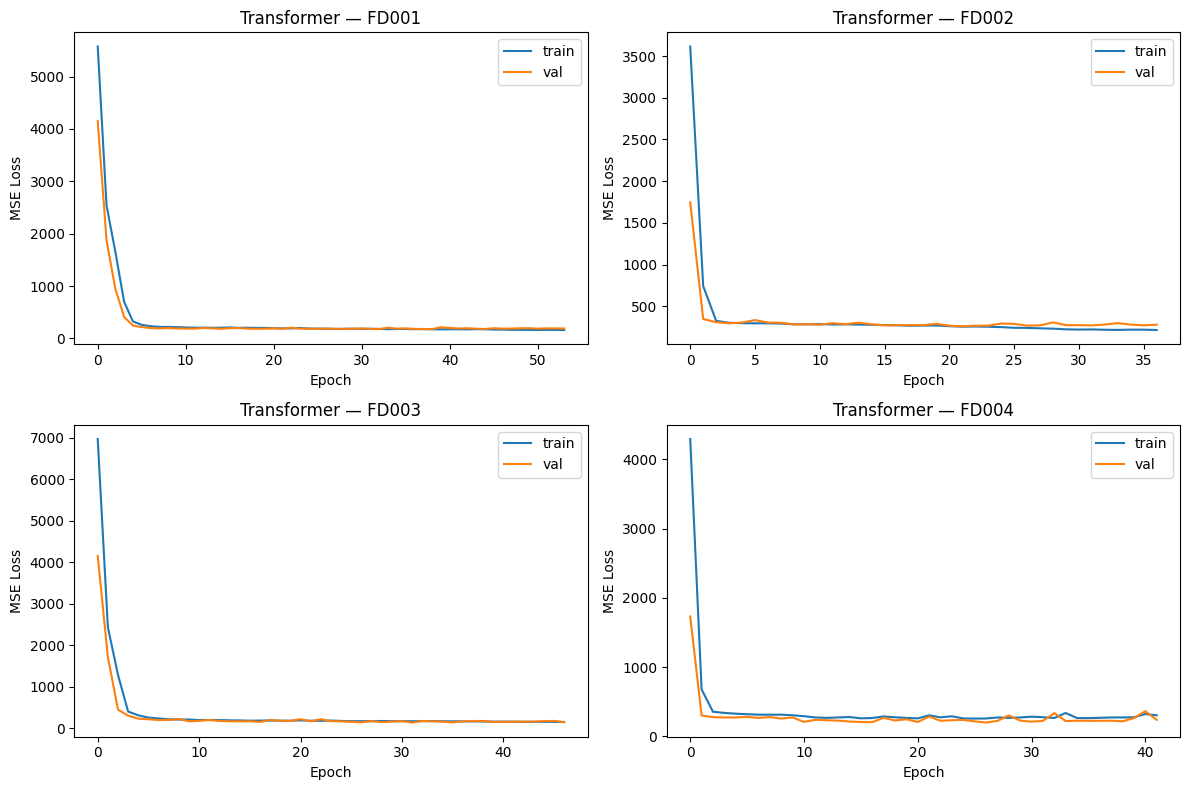

In [3]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (fd, res) in zip(axes.flatten(), results.items()):
    ax.plot(res['history']['loss'], label='train')
    ax.plot(res['history']['val_loss'], label='val')
    ax.set_title(f'Transformer — {fd}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
plt.tight_layout()
plt.savefig('../plots/04_transformer_training_curves.png', dpi=150)
plt.show()